In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
from sklearn.model_selection import train_test_split

from src.preprocess import clean_text
from src.features import prepare_features, transform
from src.model import decision_tree_model, random_forest_model
from src.evaluate import evaluate
from src.predict import predict_sample

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv("../data/twitter_training.csv", header=None)
df.columns = ['ID', 'Entity', 'Sentiment', 'Tweet']

In [3]:
df['Cleaned_Tweet'] = df['Tweet'].apply(clean_text)

C:\Users\HP\AppData\Local\Temp\ipykernel_11064\3502964764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment', y='Tweet_Length', data=df, palette='Pastel1')


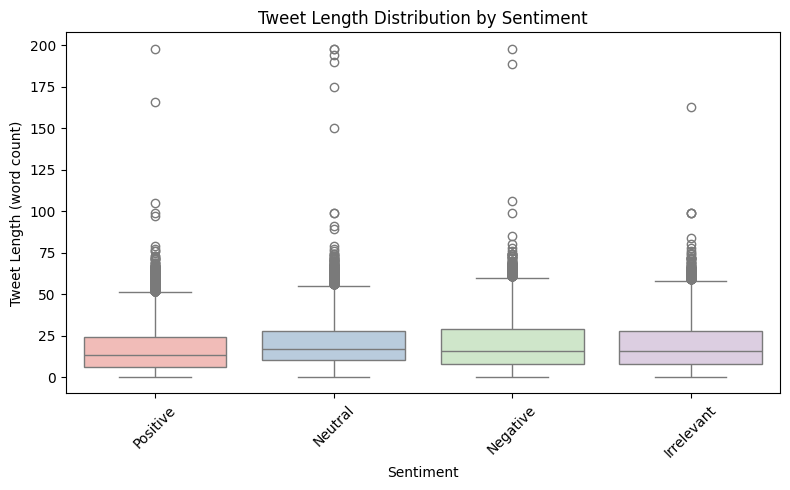

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
df['Tweet_Length'] = df['Tweet'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.boxplot(x='Sentiment', y='Tweet_Length', data=df, palette='Pastel1')
plt.title("Tweet Length Distribution by Sentiment")
plt.ylabel("Tweet Length (word count)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

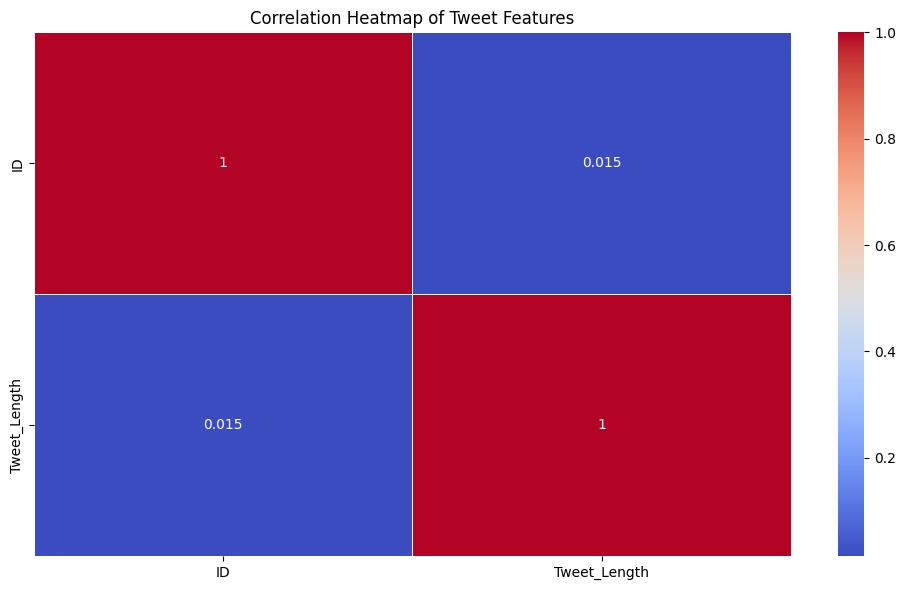

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Tweet Features")
plt.tight_layout()
plt.show()

In [4]:
X, y, tfidf, le = prepare_features(df)

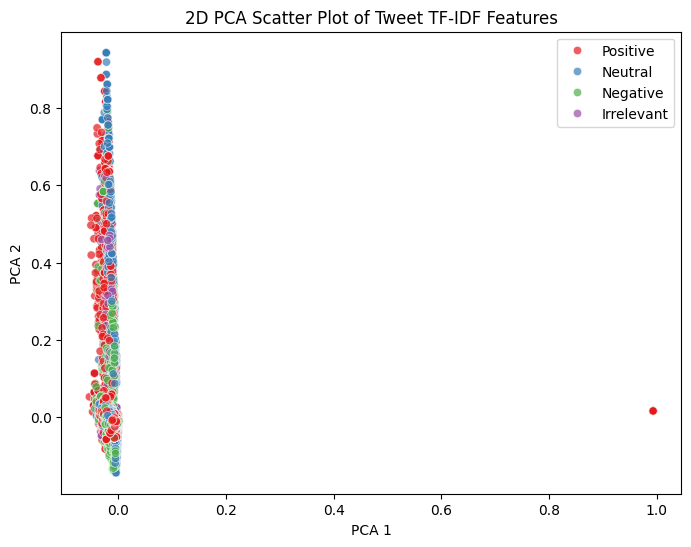

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Sentiment', palette='Set1', alpha=0.7)
plt.title("2D PCA Scatter Plot of Tweet TF-IDF Features")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_11064\1694358246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=df['Sentiment'].value_counts().index)


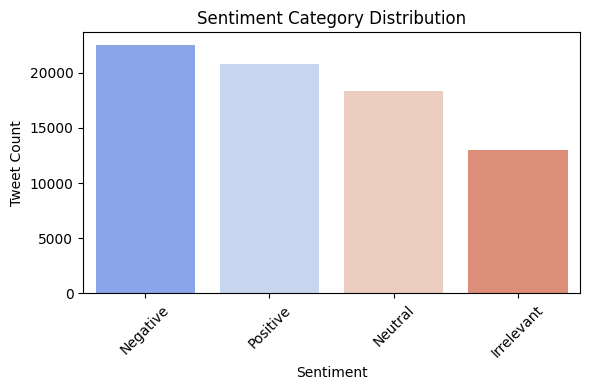

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sentiment', palette='coolwarm', order=df['Sentiment'].value_counts().index)
plt.title("Sentiment Category Distribution")
plt.ylabel("Tweet Count")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train,
    train_size=0.25,
    random_state=42,
    stratify=y_train
)

dt_model = decision_tree_model(X_sample, y_sample)
evaluate(dt_model, X_test, y_test, le)

Accuracy: 0.3855526544821584
              precision    recall  f1-score   support

  Irrelevant       0.50      0.06      0.10      2592
    Negative       0.34      0.93      0.50      4519
     Neutral       0.66      0.11      0.19      3596
    Positive       0.57      0.24      0.34      4230

    accuracy                           0.39     14937
   macro avg       0.52      0.33      0.28     14937
weighted avg       0.51      0.39      0.31     14937



In [10]:
predict_sample(rf_model, tfidf, le, clean_text)

Tweet: I love the new update, it's amazing!
Predicted Sentiment: Positive

Tweet: This app keeps crashing. Worst experience ever!
Predicted Sentiment: Negative

Tweet: Not sure how I feel about the new feature.
Predicted Sentiment: Positive

Tweet: Absolutely terrible customer service.
Predicted Sentiment: Negative

Tweet: Flight was delayed but the crew was nice.
Predicted Sentiment: Positive

